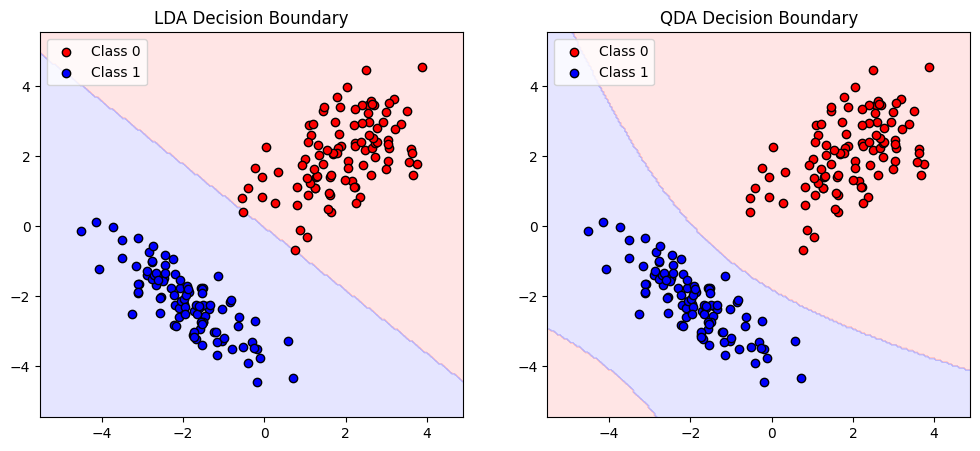

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

# Generate synthetic dataset
np.random.seed(0)
X1 = np.random.multivariate_normal([2, 2], [[1, 0.5], [0.5, 1]], 100)  # Class 1
X2 = np.random.multivariate_normal([-2, -2], [[1, -0.8], [-0.8, 1]], 100)  # Class 2
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(100), np.ones(100)))  # Labels: 0 and 1

# Train LDA and QDA
lda = LinearDiscriminantAnalysis().fit(X, y)
qda = QuadraticDiscriminantAnalysis().fit(X, y)

# Plot decision boundary function
def plot_decision_boundary(model, X, y, ax, title):
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['red', 'blue']

    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict on the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contour and scatter points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    for i, color in enumerate(cmap_bold):
        ax.scatter(X[y == i, 0], X[y == i, 1], c=color, edgecolor='k', label=f'Class {i}')

    ax.set_title(title)
    ax.legend()

# Create subplots for LDA and QDA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(lda, X, y, axes[0], "LDA Decision Boundary")
plot_decision_boundary(qda, X, y, axes[1], "QDA Decision Boundary")
plt.show()